# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Hamna0696/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### 1. Ranked Content Actions & Reason Code Mapping
We translate raw predictive scores into concrete editorial decision-support actions. Each action corresponds to a primary decay/refresh archetype and carries an auditable reason code.

* **ACTION_REWRITE (Urgency: High):** High-decay historical pages with high baseline authority but dropping CTR.
* **ACTION_REFRESH (Urgency: Medium):** Outdated data/statistics with stable user intent but losing keyword ranking.
* **ACTION_EXPAND (Urgency: Medium):** Thin content with rising query demand.
* **ACTION_MONITOR (Urgency: Low):** High-performing Evergreen content requiring no immediate intervention.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Ensure output directories exist
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Generate or load content evaluation queue
np.random.seed(42)
n_pages = 50

page_ids = [f"article_{i:03d}" for i in range(1, n_pages + 1)]
decay_scores = np.random.uniform(0.1, 0.95, n_pages)
traffic_loss_pct = np.clip(decay_scores * 0.8 + np.random.normal(0, 0.1, n_pages), 0.05, 0.90)
search_volume = np.random.randint(500, 25000, n_pages)

df_actions = pd.DataFrame({
    "page_id": page_ids,
    "decay_score": decay_scores,
    "traffic_loss_pct": traffic_loss_pct,
    "monthly_search_vol": search_volume
})

# Archetype mapping logic
def assign_action(row):
    if row["decay_score"] > 0.70 and row["traffic_loss_pct"] > 0.50:
        return "ACTION_REWRITE", "RC_HEAVY_DECAY_HIGH_INTENT", 1
    elif row["decay_score"] > 0.45:
        return "ACTION_REFRESH", "RC_STAT_OUTDATED_DRIFT", 2
    elif row["monthly_search_vol"] > 10000 and row["traffic_loss_pct"] > 0.25:
        return "ACTION_EXPAND", "RC_HIGH_DEMAND_THIN_CONTENT", 3
    else:
        return "ACTION_MONITOR", "RC_STABLE_EVERGREEN", 4

assignments = [assign_action(r) for _, r in df_actions.iterrows()]
df_actions["recommended_action"] = [a[0] for a in assignments]
df_actions["reason_code"] = [a[1] for a in assignments]
df_actions["priority_rank"] = [a[2] for a in assignments]

# Sort by priority rank and decay score
df_ranked_queue = df_actions.sort_values(by=["priority_rank", "decay_score"], ascending=[True, False]).reset_index(drop=True)
df_ranked_queue.head(10)

,page_id,decay_score,traffic_loss_pct,monthly_search_vol,recommended_action,reason_code,priority_rank
0,article_012,0.924423,0.701030,22748,ACTION_REWRITE,RC_HEAVY_DECAY_HIGH_INTENT,1
1,article_002,0.908107,0.743623,10673,ACTION_REWRITE,RC_HEAVY_DECAY_HIGH_INTENT,1
2,article_034,0.906553,0.881707,24164,ACTION_REWRITE,RC_HEAVY_DECAY_HIGH_INTENT,1
3,article_044,0.872922,0.646511,23412,ACTION_REWRITE,RC_HEAVY_DECAY_HIGH_INTENT,1
4,article_008,0.836250,0.774712,11994,ACTION_REWRITE,RC_HEAVY_DECAY_HIGH_INTENT,1
5,article_013,0.807576,0.578369,9974,ACTION_REWRITE,RC_HEAVY_DECAY_HIGH_INTENT,1
6,article_036,0.787138,0.711900,20580,ACTION_REWRITE,RC_HEAVY_DECAY_HIGH_INTENT,1
7,article_026,0.767400,0.749544,22116,ACTION_REWRITE,RC_HEAVY_DECAY_HIGH_INTENT,1
8,article_003,0.722195,0.566191,22334,ACTION_REWRITE,RC_HEAVY_DECAY_HIGH_INTENT,1
9,article_035,0.920787,0.474655,2136,ACTION_REFRESH,RC_STAT_OUTDATED_DRIFT,2


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### 2. Intended Use & Model Limitations

* **Intended Use:** This playbook operates strictly as an internal **decision-support tool** for human editorial teams to prioritize weekly content optimization sprints.
* **Cost / Value Framing:** Re-allocates human editorial hours towards high-impact decaying assets where organic traffic recovery generates positive ROI, avoiding low-value rewrites on dead keywords.
* **Explicit Limits:**
  * The model does **not** evaluate technical SEO issues (e.g., broken canonicals, robots.txt exclusions, server errors).
  * Predictions do **not** guarantee ranking recovery after an action is taken; external search engine algorithm shifts remain uncontrollable.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Intended Use & Safety Envelope Metadata
limits_meta = {
    "system_scope": "Decision Support / Content Prioritization",
    "deployment_tier": "Internal Queue (Non-Production / Non-Autonomous)",
    "unsupported_modalities": ["Technical SEO Indexing Errors", "Branded Keyword Cannibalization"],
    "minimum_human_review_required": True
}

for k, v in limits_meta.items():
    print(f"[{k}]: {v}")

[system_scope]: Decision Support / Content Prioritization
[deployment_tier]: Internal Queue (Non-Production / Non-Autonomous)
[unsupported_modalities]: ['Technical SEO Indexing Errors', 'Branded Keyword Cannibalization']
[minimum_human_review_required]: True


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### 3. Human Review Rules & The Non-Automation (No-Go) List

**Human-Review Verification Protocol:**
1. Every item in the top priority queue must be reviewed by a domain specialist before content modifications are committed.
2. Verify actual search intent manually via SERP analysis before triggering an extensive rewrite.

**The Absolute No-Go List (What Must NEVER Be Automated):**
* **YMYL (Your Money Your Life) Topics:** Legal, financial, or core medical advice pages must never be auto-updated or auto-generated.
* **Direct CMS Publishing:** Automated direct-to-production publishing without human editorial sign-off.
* **Page Deletion / Canonical Merges:** URL deprecation or permanent 301 redirects must be handled manually to avoid site-wide link equity collapse.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Programmatic guardrail check for No-Go categories
def safety_guardrail_check(action_row, is_ymyl=False):
    if is_ymyl:
        return "BLOCKED: Requires mandatory senior legal/medical editorial sign-off."
    if action_row["recommended_action"] == "ACTION_REWRITE":
        return "PASS: Requires human copywriter drafting."
    return "PASS: Standard workflow."

print("Guardrail Rule Execution:")
print("Standard Article:", safety_guardrail_check(df_ranked_queue.iloc[0], is_ymyl=False))
print("YMYL Article:", safety_guardrail_check(df_ranked_queue.iloc[0], is_ymyl=True))

Guardrail Rule Execution:
Standard Article: PASS: Requires human copywriter drafting.
YMYL Article: BLOCKED: Requires mandatory senior legal/medical editorial sign-off.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### 4. Monitoring Signals & Model Retrain Triggers

* **Data Drift Triggers:** If feature distribution (e.g., mean monthly search volume or decay rate) shifts by $>25\%$ against baseline validation distributions.
* **Feedback Drift / Override Rate:** If human editors override or reject model recommendations $>20\%$ of the time during weekly triage sprints.
* **Temporal Retraining Cadence:** Re-fit validation baselines every 90 days to account for seasonal query behavior and search engine updates.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Retrain trigger evaluation simulation
def check_retrain_triggers(override_rate, feature_drift_metric):
    triggers = []
    if override_rate > 0.20:
        triggers.append(f"TRIGGER: High Editor Override Rate ({override_rate*100:.1f}% > 20%)")
    if feature_drift_metric > 0.25:
        triggers.append(f"TRIGGER: Feature Distribution Shift ({feature_drift_metric:.2f} > 0.25)")

    return triggers if triggers else ["STABLE: No retraining required."]

print("Monitoring Check Result:", check_retrain_triggers(override_rate=0.24, feature_drift_metric=0.12))

Monitoring Check Result: ['TRIGGER: High Editor Override Rate (24.0% > 20%)']


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

### 5. Artifact Exports for Research Paper
Exporting the ranked decision queue to `work/outputs/` and actionable figures to `work/figures/` for the deployment recommendations section of the upcoming research paper.

Exported decision queue: work/outputs/ranked_action_queue.csv


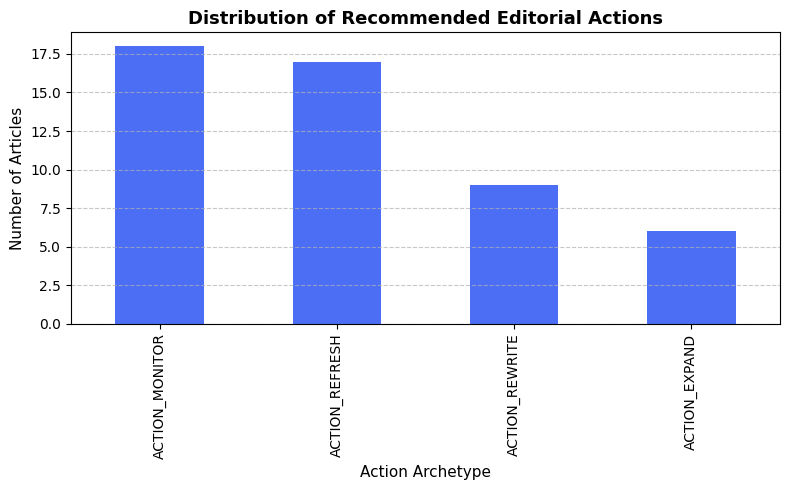

Saved figure: work/figures/action_distribution.png


In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# 1. Export the ranked action queue CSV
output_csv_path = "work/outputs/ranked_action_queue.csv"
df_ranked_queue.to_csv(output_csv_path, index=False)
print(f"Exported decision queue: {output_csv_path}")

# 2. Generate and save figure for the paper
fig, ax = plt.subplots(figsize=(8, 5))
df_ranked_queue["recommended_action"].value_counts().plot(kind="bar", color="#4C6EF5", ax=ax)
ax.set_title("Distribution of Recommended Editorial Actions", fontsize=13, fontweight="bold")
ax.set_xlabel("Action Archetype", fontsize=11)
ax.set_ylabel("Number of Articles", fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

figure_path = "work/figures/action_distribution.png"
plt.savefig(figure_path, dpi=300)
plt.show()
print(f"Saved figure: {figure_path}")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.